# Post processing of light curves

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from astropy.table import Table
import sys
import os
from astropy.timeseries import LombScargle

sys.path.insert(1, 'scripts/')
sys.path.insert(1, 'stella/')
import stella


/Users/azib/micromamba/envs/nets2/lib/python3.8/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /Users/azib/.lightkurve/cache. Please move all the files in the legacy directory /Users/azib/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


### Functions

In [2]:
def load_predictions(file_path):
    """Load the pickle file containing predictions"""
    data = []
    import pickle
    with open(file_path, "rb") as f:
        while True:
            try:
                data.append(pickle.load(f))
            except EOFError:
                break
    return data

def lombscargle(time, flux):
    """
    Return the peak Lomb-Scargle power for a given time and flux array.
    """
    frequency, power = LombScargle(time, flux).autopower()
    return np.max(power)


In [3]:
df = pd.DataFrame(load_predictions('../predictions/test3.pkl'))
df.head()

,ID,t_pred,pred,is_interesting,time,flux,predictions,original_time,original_flux
0,109681480,1516.014839,0.388872,0,"[1491.6606284913414, 1491.681462154886, 1491.7...","[0.24676894, 0.21566653, 0.34055212, 0.3152161...","[0.38887215, 0.38887215, 0.38887215, 0.3888721...",NaN,NaN
1,108119677,1515.910424,0.388872,0,"[1491.7854081341322, 1491.8062417498923, 1491....","[0.9442265, 0.79969054, 0.80963695, 0.9166897,...","[0.38887215, 0.38887215, 0.38887215, 0.3888721...",NaN,NaN
2,107620713,1491.660721,0.388872,0,"[1491.6607214409873, 1491.6815550280567, 1491....","[0.9220859, 0.9849754, 1.0, 0.9900166, 0.96437...","[0.38887215, 0.38887215, 0.38887215, 0.3888721...",NaN,NaN
3,99251836,1516.077498,0.388872,0,"[1491.9110511453919, 1491.9318846099752, 1491....","[0.13777056, 0.22101024, 0.3755232, 0.35394782...","[0.38887215, 0.38887215, 0.38887215, 0.3888721...",NaN,NaN
4,114108687,1515.868665,0.388872,0,"[1491.6602191690174, 1491.6810528606673, 1491....","[0.07021078, 0.3818677, 0.29870293, 0.28674343...","[0.38887215, 0.38887215, 0.38887215, 0.3888721...",NaN,NaN


In [4]:
df = df[df.is_interesting == 1]

### Multi-event detection and filtering

In [5]:
def detect_all_events(row, threshold=0.8, min_consecutive=5):
    """Find all consecutive high-prediction regions"""
    predictions = row['predictions']
    time = row['time']
    
    high_indices = np.where(predictions >= threshold)[0]
    if len(high_indices) == 0:
        return []
    
    events = []
    current_event = [high_indices[0]]
    
    for i in range(1, len(high_indices)):
        if high_indices[i] == high_indices[i-1] + 1:
            current_event.append(high_indices[i])
        else:
            if len(current_event) >= min_consecutive:
                peak_idx = current_event[np.argmax(predictions[current_event])]
                events.append({'n_points': len(current_event), 'max_prob': predictions[peak_idx]})
            current_event = [high_indices[i]]
    
    # Last event
    if len(current_event) >= min_consecutive:
        peak_idx = current_event[np.argmax(predictions[current_event])]
        events.append({'n_points': len(current_event), 'max_prob': predictions[peak_idx]})
    
    return events

In [6]:
# Apply multi-event detection
df['all_events'] = df.apply(detect_all_events, axis=1)
df['n_events'] = df['all_events'].apply(len)

# Calculate maximum prediction from detected events (for compatibility with existing code)
def get_max_pred_from_events(events):
    if len(events) == 0:
        return 0.0
    return max(event['max_prob'] for event in events)

df['pred_filtered'] = df['all_events'].apply(get_max_pred_from_events)

# Keep only lightcurves with valid events and high enough maximum prediction
df = df[(df['n_events'] > 0) & (df['pred_filtered'] > 0.8)]

### Filtering and Lomb-Scargle

In [7]:
df = df.sort_values(by='pred_filtered', ascending=False)
df["ls_peak_power"] = df.apply(lambda row: lombscargle(row["time"], row["flux"]), axis=1)
df = df[df.ls_peak_power < 0.2]
print(f"After Lomb-Scargle filtering: {len(df)}")

After Lomb-Scargle filtering: 15


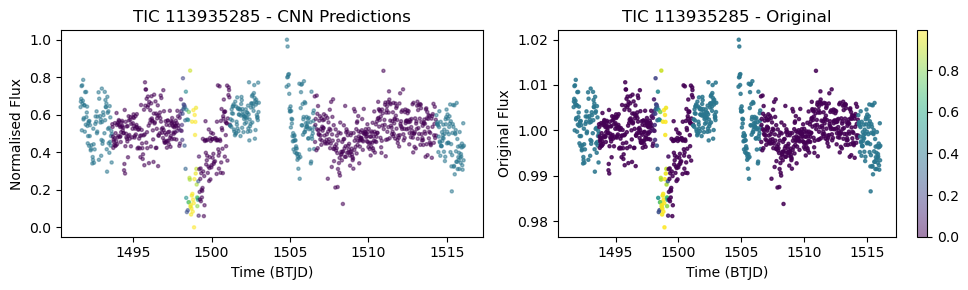

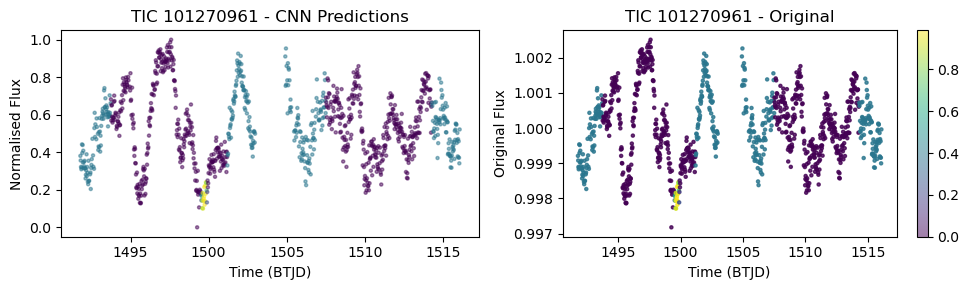

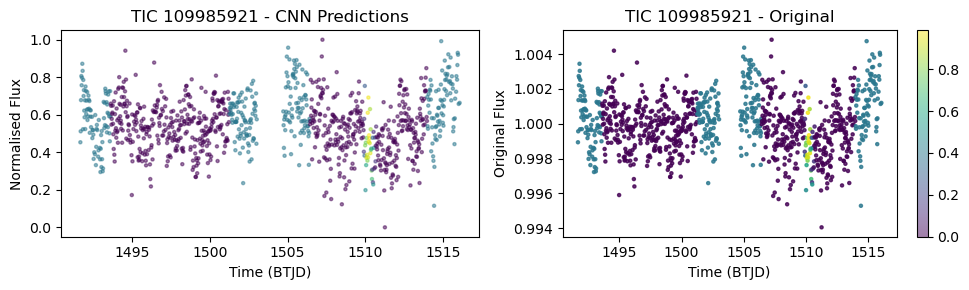

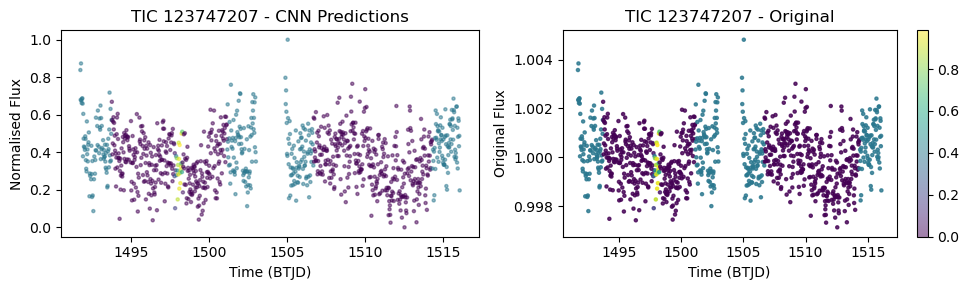

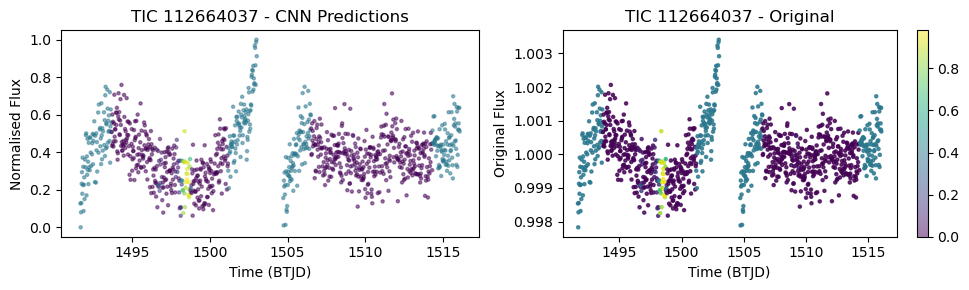

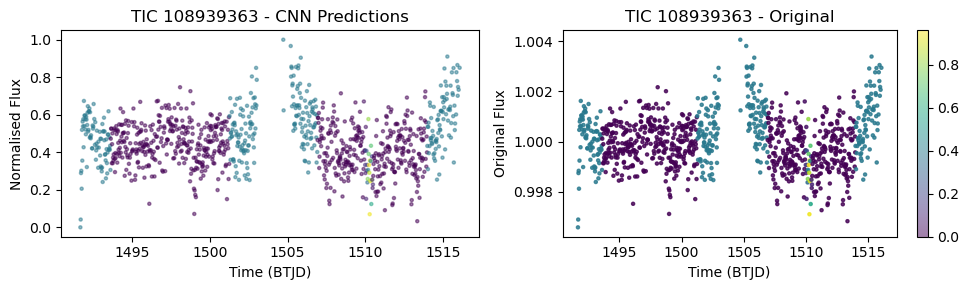

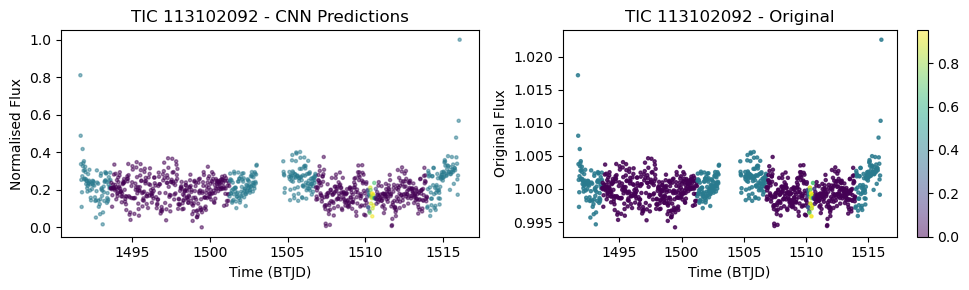

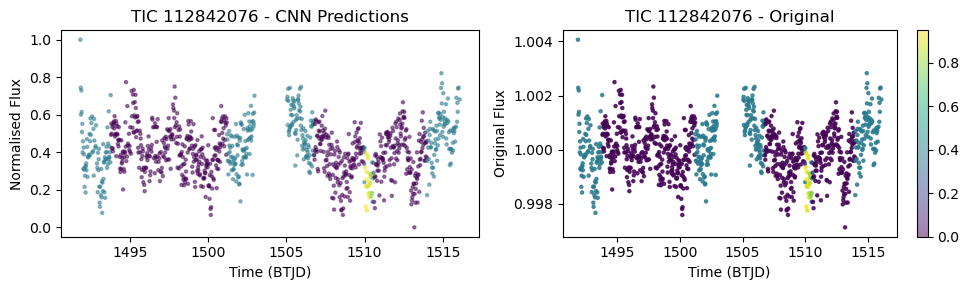

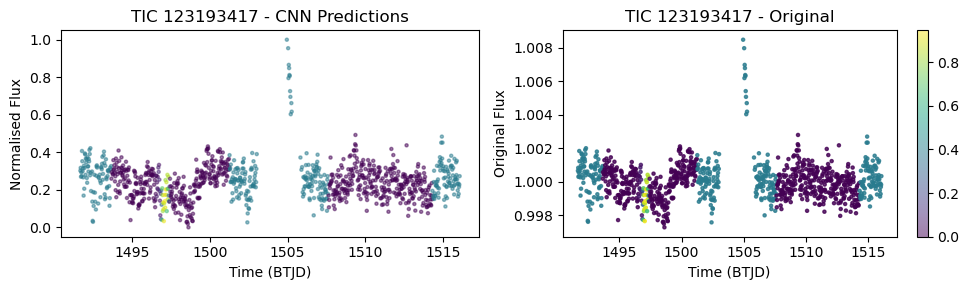

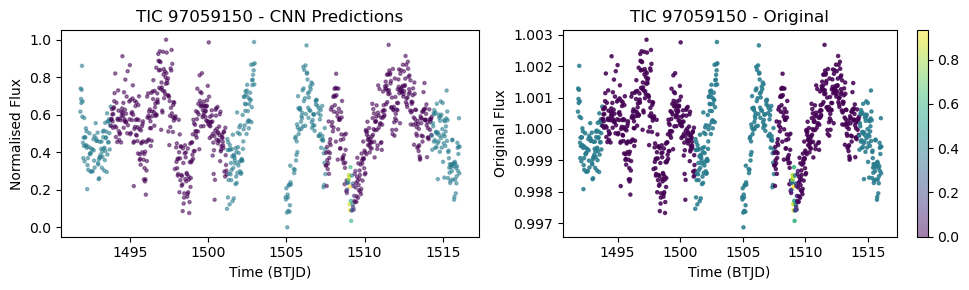

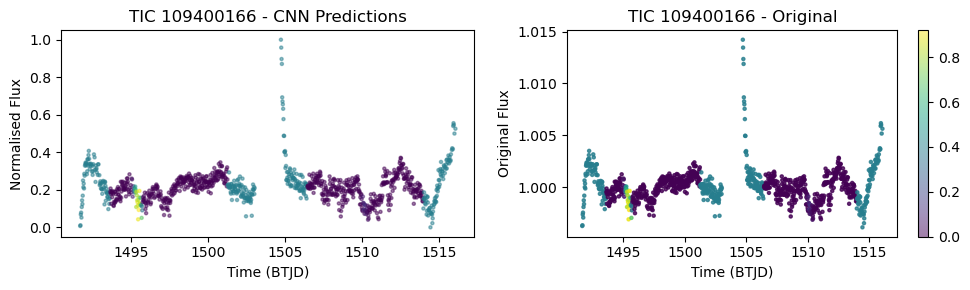

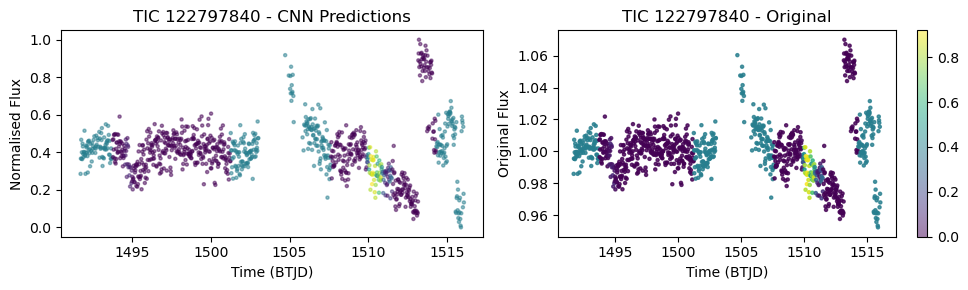

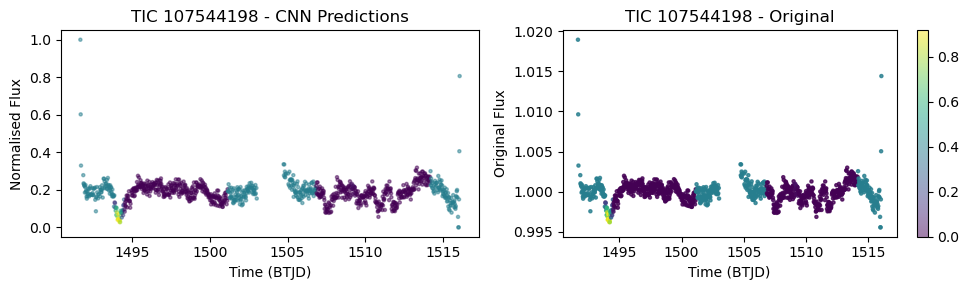

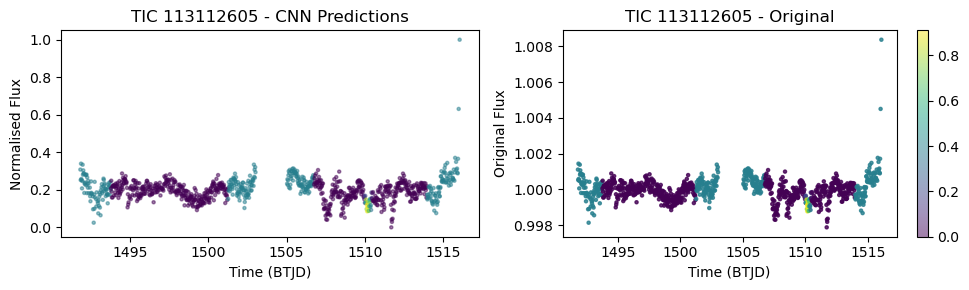

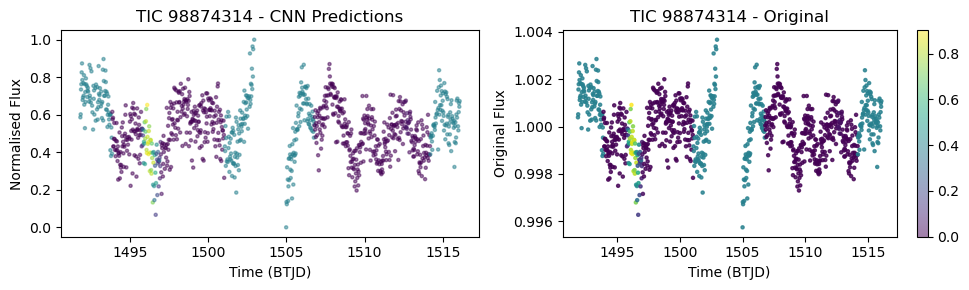

In [8]:
for i in df.index:
    time = df.loc[i].time
    flux = df.loc[i].flux
    original_flux = df.loc[i].original_flux 
    preds = df.loc[i].predictions
    ID = df.loc[i].ID
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
    
    scatter = ax1.scatter(time, flux, c=preds, s=5, alpha=0.5, cmap='viridis')
    ax1.set_title(f'TIC {ID} - CNN Predictions')
    ax1.set_xlabel('Time (BTJD)')
    ax1.set_ylabel('Normalised Flux')
    
    ax2.scatter(time, original_flux,c=preds,s=5, alpha=0.8)
    ax2.set_title(f'TIC {ID} - Original')
    ax2.set_xlabel('Time (BTJD)')
    ax2.set_ylabel('Original Flux')
    plt.colorbar(scatter, ax=ax2)

    
    plt.tight_layout()
    plt.show()

------

In [9]:
print(f"Lightcurves with events: {len(df)}")
print(f"With multiple events: {len(df[df.n_events > 1])}")
if len(df[df.n_events > 1]) > 0:
    print(f"TIC ID(s): {df[df.n_events > 1]['ID'].tolist()}")

Lightcurves with events: 15
With multiple events: 1
TIC ID(s): [122797840]
